In [ ]:
import torch
import torch.nn as nn

# ----------------------------
# 1. SELF-ATTENTION MODULE
# ----------------------------
class SelfAttention(nn.Module):
    def __init__(self, embed_size, heads):
        super(SelfAttention, self).__init__()
        self.embed_size = embed_size
        self.heads = heads
        self.head_dim = embed_size // heads

        assert self.head_dim * heads == embed_size, "Embedding size must be divisible by heads"

        # Linear layers for queries, keys, values (each per head)
        self.values = nn.Linear(self.head_dim, self.head_dim, bias=False)
        self.keys = nn.Linear(self.head_dim, self.head_dim, bias=False)
        self.queries = nn.Linear(self.head_dim, self.head_dim, bias=False)

        # Final linear layer after concatenating all heads
        self.fc_out = nn.Linear(embed_size, embed_size)

    def forward(self, values, keys, query, mask):
        N = query.shape[0]  # batch size
        value_len, key_len, query_len = values.shape[1], keys.shape[1], query.shape[1]

        # Split embeddings into multiple heads (N, seq_len, heads, head_dim)
        values = values.reshape(N, value_len, self.heads, self.head_dim)
        keys = keys.reshape(N, key_len, self.heads, self.head_dim)
        queries = query.reshape(N, query_len, self.heads, self.head_dim)

        # Linear transformation for each
        values = self.values(values)
        keys = self.keys(keys)
        queries = self.queries(queries)

        # Compute scaled dot-product attention scores
        energy = torch.einsum("nqhd,nkhd->nhqk", [queries, keys])  # shape: (N, heads, query_len, key_len)

        if mask is not None:
            energy = energy.masked_fill(mask == 0, float("-1e20"))

        attention = torch.softmax(energy / (self.head_dim ** 0.5), dim=3)

        # Weighted sum of values
        out = torch.einsum("nhql,nlhd->nqhd", [attention, values])  # shape: (N, query_len, heads, head_dim)

        # Reshape and pass through final linear layer
        out = out.reshape(N, query_len, self.heads * self.head_dim)
        return self.fc_out(out)


# ----------------------------
# 2. TRANSFORMER BLOCK
# ----------------------------
class TransformerBlock(nn.Module):
    def __init__(self, embed_size, heads, dropout, forward_expansion):
        super(TransformerBlock, self).__init__()
        self.attention = SelfAttention(embed_size, heads)

        # Normalization and Feedforward
        self.norm1 = nn.LayerNorm(embed_size)
        self.norm2 = nn.LayerNorm(embed_size)
        self.feed_forward = nn.Sequential(
            nn.Linear(embed_size, forward_expansion * embed_size),
            nn.ReLU(),
            nn.Linear(forward_expansion * embed_size, embed_size),
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, value, key, query, mask):
        attention = self.attention(value, key, query, mask)
        x = self.dropout(self.norm1(attention + query))  # residual + norm
        forward = self.feed_forward(x)
        return self.dropout(self.norm2(forward + x))  # another residual + norm


# ----------------------------
# 3. ENCODER
# ----------------------------
class Encoder(nn.Module):
    def __init__(self, src_vocab_size, embed_size, num_layers, heads, device, forward_expansion, dropout, max_length):
        super(Encoder, self).__init__()
        self.embed_size = embed_size
        self.device = device

        # Token and Positional Embeddings
        self.word_embedding = nn.Embedding(src_vocab_size, embed_size)
        self.position_embedding = nn.Embedding(max_length, embed_size)

        # Stack of Transformer blocks
        self.layers = nn.ModuleList([
            TransformerBlock(embed_size, heads, dropout, forward_expansion)
            for _ in range(num_layers)
        ])
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask):
        N, seq_length = x.shape
        positions = torch.arange(0, seq_length).expand(N, seq_length).to(self.device)

        out = self.dropout(self.word_embedding(x) + self.position_embedding(positions))

        for layer in self.layers:
            out = layer(out, out, out, mask)
        return out


# ----------------------------
# 4. DECODER BLOCK
# ----------------------------
class DecoderBlock(nn.Module):
    def __init__(self, embed_size, heads, dropout, forward_expansion):
        super(DecoderBlock, self).__init__()
        self.attention = SelfAttention(embed_size, heads)
        self.norm = nn.LayerNorm(embed_size)
        self.transformer_block = TransformerBlock(embed_size, heads, dropout, forward_expansion)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, value, key, src_mask, trg_mask):
        attention = self.attention(x, x, x, trg_mask)
        query = self.dropout(self.norm(attention + x))
        return self.transformer_block(value, key, query, src_mask)


# ----------------------------
# 5. DECODER
# ----------------------------
class Decoder(nn.Module):
    def __init__(self, trg_vocab_size, embed_size, num_layers, heads, forward_expansion, dropout, device, max_length):
        super(Decoder, self).__init__()
        self.embed_size = embed_size
        self.device = device
        self.word_embedding = nn.Embedding(trg_vocab_size, embed_size)
        self.position_embedding = nn.Embedding(max_length, embed_size)

        self.layers = nn.ModuleList([
            DecoderBlock(embed_size, heads, dropout, forward_expansion)
            for _ in range(num_layers)
        ])
        self.fc_out = nn.Linear(embed_size, trg_vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_out, src_mask, trg_mask):
        N, seq_length = x.shape
        positions = torch.arange(0, seq_length).expand(N, seq_length).to(self.device)
        x = self.dropout(self.word_embedding(x) + self.position_embedding(positions))

        for layer in self.layers:
            x = layer(x, enc_out, enc_out, src_mask, trg_mask)
        return self.fc_out(x)


# ----------------------------
# 6. FULL TRANSFORMER
# ----------------------------
class Transformer(nn.Module):
    def __init__(self, src_vocab_size, trg_vocab_size, src_pad_idx, trg_pad_idx,
                 embed_size=256, num_layers=6, heads=8, forward_expansion=4,
                 dropout=0.1, device="cuda", max_length=100):
        super(Transformer, self).__init__()
        self.encoder = Encoder(src_vocab_size, embed_size, num_layers, heads,
                               device, forward_expansion, dropout, max_length)
        self.decoder = Decoder(trg_vocab_size, embed_size, num_layers, heads,
                               forward_expansion, dropout, device, max_length)
        self.src_pad_idx = src_pad_idx
        self.trg_pad_idx = trg_pad_idx
        self.device = device

    def make_src_mask(self, src):
        return (src != self.src_pad_idx).unsqueeze(1).unsqueeze(2).to(self.device)

    def make_trg_mask(self, trg):
        N, trg_len = trg.shape

        # Lower triangular matrix with True where attention is allowed
        trg_mask = torch.tril(torch.ones((trg_len, trg_len), device=self.device)).bool()
        trg_mask = trg_mask.expand(N, 1, trg_len, trg_len)

        # Padding mask: True for real tokens, False for pad tokens
        trg_pad_mask = (trg != self.trg_pad_idx).unsqueeze(1).unsqueeze(2)  # (N, 1, 1, trg_len)

        return trg_mask & trg_pad_mask


    def forward(self, src, trg):
        src_mask = self.make_src_mask(src)
        trg_mask = self.make_trg_mask(trg)
        enc_src = self.encoder(src, src_mask)
        return self.decoder(trg, enc_src, src_mask, trg_mask)


# ----------------------------
# 7. TESTING
# ----------------------------
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    src = torch.tensor([[1, 5, 6, 4, 3], [1, 8, 7, 6, 2]]).to(device)
    trg = torch.tensor([[1, 7, 4, 3], [1, 9, 2, 5]]).to(device)

    model = Transformer(
        src_vocab_size=20,
        trg_vocab_size=20,
        src_pad_idx=0,
        trg_pad_idx=0,
        embed_size=256,
        num_layers=2,
        heads=8,
        forward_expansion=4,
        dropout=0.1,
        device=device,
        max_length=100,
    ).to(device)

    out = model(src, trg[:, :-1])
    print(out.shape)  # Output shape: (batch_size, trg_seq_len - 1, trg_vocab_size)

torch.Size([2, 3, 20])


## transformer libaray

In [2]:
from huggingface_hub import login

login()

In [4]:
!pip install --upgrade datasets fsspec


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 19.3 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
  Attempting uninstall: datasets
    Found existing installation: datasets 2.14.4
    Uninstalling datasets-2.14.4:
      Successfully uninstalled datasets-2.14.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.2 requires fsspec==2025.3.2, but you have fsspec 2025.3.0 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; pl

In [3]:
from datasets import load_dataset
from transformers import AutoTokenizer

dataset = load_dataset("yelp_review_full")
tokenizer = AutoTokenizer.from_pretrained("google-bert/bert-base-cased")

def tokenize(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True)

dataset = dataset.map(tokenize, batched=True)

README.md:   0%|          | 0.00/6.72k [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/299M [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/23.5M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/650000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/50000 [00:00<?, ? examples/s]

...

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

Map:   0%|          | 0/650000 [00:00<?, ? examples/s]

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [4]:
small_train = dataset["train"].shuffle(seed=42).select(range(1000))
small_eval = dataset["test"].shuffle(seed=42).select(range(1000))

In [5]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained("google-bert/bert-base-cased", num_labels=5)
"Some weights of BertForSequenceClassification were not initialized from the model checkpoint at google-bert/bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']"
"You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference."

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at google-bert/bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


'You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.'

In [7]:
! pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.3 MB/s eta 0:00:00


In [8]:
import numpy as np
import evaluate

metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    # convert the logits to their predicted class
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

In [9]:
import transformers, accelerate
print("transformers:", transformers.__version__)
print("accelerate:", accelerate.__version__)


transformers: 4.52.4
accelerate: 1.7.0


In [14]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="yelp_review_classifier",
    per_device_train_batch_size=16,
    num_train_epochs=1,  # Reduce from 3 to 1
    max_steps=500,       # Or set a hard cap on steps
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=50,
    report_to="none",    # Disable W&B if not needed
)
from transformers import Trainer, TrainingArguments
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [15]:
from transformers import Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
    compute_metrics=compute_metrics,
)
trainer.train()

Step,Training Loss
50,1.092200
100,0.877600
150,0.978100
200,0.971400
250,1.074700
300,0.992600
350,0.949800
400,0.930300
450,0.931700
500,0.949400


TrainOutput(global_step=500, training_loss=0.9747766342163086, metrics={'train_runtime': 759.8728, 'train_samples_per_second': 10.528, 'train_steps_per_second': 0.658, 'total_flos': 2104945139712000.0, 'train_loss': 0.9747766342163086, 'epoch': 0.012307692307692308})

In [16]:
trainer.push_to_hub()

Uploading...:   0%|          | 0.00/433M [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/UDHOV/yelp_review_classifier/commit/f0fea01d145f8e0c92286f7056b177c3c86d5738', commit_message='End of training', commit_description='', oid='f0fea01d145f8e0c92286f7056b177c3c86d5738', pr_url=None, repo_url=RepoUrl('https://huggingface.co/UDHOV/yelp_review_classifier', endpoint='https://huggingface.co', repo_type='model', repo_id='UDHOV/yelp_review_classifier'), pr_revision=None, pr_num=None)

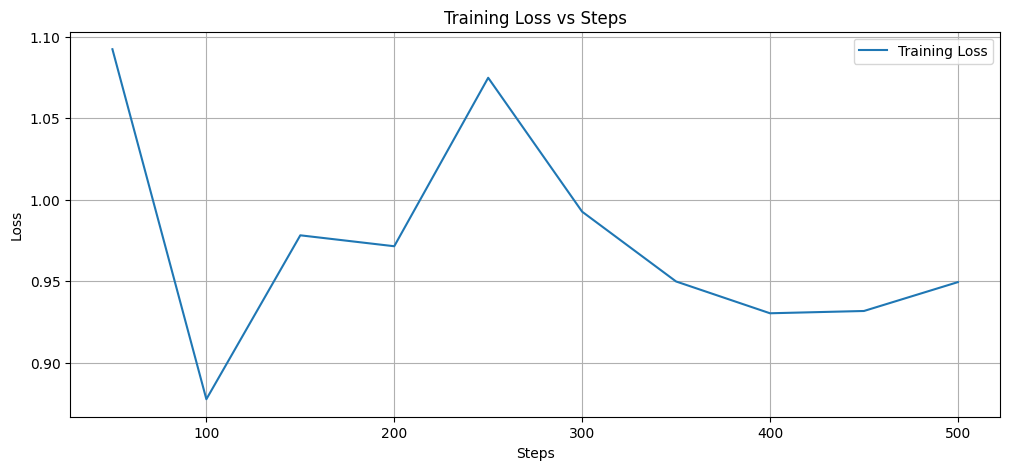

In [17]:
import matplotlib.pyplot as plt

# Extract log history
logs = trainer.state.log_history

# Initialize lists
train_loss, eval_loss, eval_accuracy, steps = [], [], [], []

# Populate metrics
for entry in logs:
    if "loss" in entry and "epoch" in entry:
        train_loss.append(entry["loss"])
        steps.append(entry["step"])
    if "eval_loss" in entry:
        eval_loss.append(entry["eval_loss"])
    if "eval_accuracy" in entry:
        eval_accuracy.append(entry["eval_accuracy"])

# Plot training loss
plt.figure(figsize=(12, 5))
plt.plot(steps, train_loss, label="Training Loss")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Training Loss vs Steps")
plt.legend()
plt.grid(True)
plt.show()

# Plot eval accuracy
if eval_accuracy:
    plt.figure(figsize=(12, 5))
    plt.plot(range(len(eval_accuracy)), eval_accuracy, marker='o', label="Eval Accuracy")
    plt.xlabel("Evaluation Steps")
    plt.ylabel("Accuracy")
    plt.title("Evaluation Accuracy over Epochs")
    plt.legend()
    plt.grid(True)
    plt.show()

